In [1]:
import pandas as pd
import numpy as np

results_all = [
    # =========================
    # EARLY ABSOLUTE XYZ STAGE
    # =========================
    {
        "ExperimentGroup": "Absolute Coordinate Regression",
        "Model": "Linear Regression",
        "Variant": "Baseline",
        "InputRepresentation": "Per-residue engineered evolutionary features",
        "TargetType": "Absolute XYZ coordinates",
        "ArchitectureNotes": "Classical linear baseline for direct coordinate prediction",
        "RMSE": 910.548,   # fill if available
        "MAE": 646.0600123329912,    # fill if available
        "R2": 0.02542293071746826
    },
    {
        "ExperimentGroup": "Absolute Coordinate Regression",
        "Model": "SVR",
        "Variant": "RBF Kernel",
        "InputRepresentation": "Per-residue engineered evolutionary features",
        "TargetType": "Absolute XYZ coordinates",
        "ArchitectureNotes": "Support Vector Regression with RBF kernel",
        "RMSE": 914.2172198115719,
        "MAE": 630.8269653320312,
        "R2": 0.02542293071746826
    },
    {
        "ExperimentGroup": "Absolute Coordinate Regression",
        "Model": "XGBoost / Tree Ensemble",
        "Variant": "Early boosting baseline",
        "InputRepresentation": "Per-residue engineered evolutionary features",
        "TargetType": "Absolute XYZ coordinates",
        "ArchitectureNotes": "Early attempt before switching to biologically meaningful distance targets",
        "RMSE": 855.1081802906577,
        "MAE": 577.7850341796875,
        "R2": 0.14737212657928467
    },

    # =========================
    # FINAL DISTANCE-TARGET STAGE
    # =========================
    {
        "ExperimentGroup": "Distance Target Regression",
        "Model": "SVR",
        "Variant": "Sliding-window baseline",
        "InputRepresentation": "Sliding window (11x41 -> 451 flattened)",
        "TargetType": "dist_i1, dist_i2, dist_i4, dist_i8",
        "ArchitectureNotes": "Linear baseline on final distance-target setup",
        "RMSE": 902.5429709117792,   # fill if you ran it on final setup
        "MAE": 605.7903000366231,    # fill if you ran it on final setup
        "R2": 0.05015399982014612      # fill if you ran it on final setup
    },
    {
        "ExperimentGroup": "Distance Target Regression",
        "Model": "XGBoost",
        "Variant": "Final tuned boosting model",
        "InputRepresentation": "Sliding window (11x41 -> 451 flattened)",
        "TargetType": "dist_i1, dist_i2, dist_i4, dist_i8",
        "ArchitectureNotes": "Best-performing model on engineered local context features",
        "RMSE": 629.3886418581129,
        "MAE": 175.75497436523438,
        "R2": 0.6281043291091919
    },
    {
        "ExperimentGroup": "Distance Target Regression",
        "Model": "MLP",
        "Variant": "Dense Network v1",
        "InputRepresentation": "Sliding window (11x41), flattened inside network",
        "TargetType": "dist_i1, dist_i2, dist_i4, dist_i8",
        "ArchitectureNotes": "451 -> 512 -> 256 -> 128 -> 4 with ReLU and dropout",
        "RMSE": 695.4342168746085,
        "MAE": 228.09283447265625,
        "R2": 0.5485751628875732
    },
    {
        "ExperimentGroup": "Distance Target Regression",
        "Model": "CNN",
        "Variant": "1D CNN Basic",
        "InputRepresentation": "Sliding window (11x41) as sequence tensor",
        "TargetType": "dist_i1, dist_i2, dist_i4, dist_i8",
        "ArchitectureNotes": "Stacked Conv1D blocks + BatchNorm + AdaptiveAvgPool + FC head",
        "RMSE": 759.0679729115174,
        "MAE": 242.0788116455078,
        "R2": 0.42530763149261475
    },
    {
        "ExperimentGroup": "Distance Target Regression",
        "Model": "CNN",
        "Variant": "1D CNN Multi-scale",
        "InputRepresentation": "Sliding window (11x41) as sequence tensor",
        "TargetType": "dist_i1, dist_i2, dist_i4, dist_i8",
        "ArchitectureNotes": "Parallel Conv1D branches (k=3,5,7) + fusion + FC head; target normalization used",
        "RMSE": 757.4517723921438,
        "MAE": 204.02911376953125,
        "R2": 0.4288851022720337
    }
]

results_all_df = pd.DataFrame(results_all)
results_all_df

,ExperimentGroup,Model,Variant,InputRepresentation,TargetType,ArchitectureNotes,RMSE,MAE,R2
0,Absolute Coordinate Regression,Linear Regression,Baseline,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Classical linear baseline for direct coordinat...,910.548000,646.060012,0.025423
1,Absolute Coordinate Regression,SVR,RBF Kernel,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Support Vector Regression with RBF kernel,914.217220,630.826965,0.025423
2,Absolute Coordinate Regression,XGBoost / Tree Ensemble,Early boosting baseline,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Early attempt before switching to biologically...,855.108180,577.785034,0.147372
3,Distance Target Regression,SVR,Sliding-window baseline,Sliding window (11x41 -> 451 flattened),"dist_i1, dist_i2, dist_i4, dist_i8",Linear baseline on final distance-target setup,902.542971,605.790300,0.050154
4,Distance Target Regression,XGBoost,Final tuned boosting model,Sliding window (11x41 -> 451 flattened),"dist_i1, dist_i2, dist_i4, dist_i8",Best-performing model on engineered local cont...,629.388642,175.754974,0.628104
5,Distance Target Regression,MLP,Dense Network v1,"Sliding window (11x41), flattened inside network","dist_i1, dist_i2, dist_i4, dist_i8",451 -> 512 -> 256 -> 128 -> 4 with ReLU and dr...,695.434217,228.092834,0.548575
6,Distance Target Regression,CNN,1D CNN Basic,Sliding window (11x41) as sequence tensor,"dist_i1, dist_i2, dist_i4, dist_i8",Stacked Conv1D blocks + BatchNorm + AdaptiveAv...,759.067973,242.078812,0.425308
7,Distance Target Regression,CNN,1D CNN Multi-scale,Sliding window (11x41) as sequence tensor,"dist_i1, dist_i2, dist_i4, dist_i8","Parallel Conv1D branches (k=3,5,7) + fusion + ...",757.451772,204.029114,0.428885


In [2]:
abs_df = results_all_df[
    results_all_df["ExperimentGroup"] == "Absolute Coordinate Regression"
].copy()

abs_df = abs_df.sort_values(by="R2", ascending=False, na_position="last").reset_index(drop=True)
abs_df

,ExperimentGroup,Model,Variant,InputRepresentation,TargetType,ArchitectureNotes,RMSE,MAE,R2
0,Absolute Coordinate Regression,XGBoost / Tree Ensemble,Early boosting baseline,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Early attempt before switching to biologically...,855.10818,577.785034,0.147372
1,Absolute Coordinate Regression,Linear Regression,Baseline,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Classical linear baseline for direct coordinat...,910.54800,646.060012,0.025423
2,Absolute Coordinate Regression,SVR,RBF Kernel,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Support Vector Regression with RBF kernel,914.21722,630.826965,0.025423


In [3]:
dist_df = results_all_df[
    results_all_df["ExperimentGroup"] == "Distance Target Regression"
].copy()

dist_df = dist_df.sort_values(by="R2", ascending=False, na_position="last").reset_index(drop=True)
dist_df

,ExperimentGroup,Model,Variant,InputRepresentation,TargetType,ArchitectureNotes,RMSE,MAE,R2
0,Distance Target Regression,XGBoost,Final tuned boosting model,Sliding window (11x41 -> 451 flattened),"dist_i1, dist_i2, dist_i4, dist_i8",Best-performing model on engineered local cont...,629.388642,175.754974,0.628104
1,Distance Target Regression,MLP,Dense Network v1,"Sliding window (11x41), flattened inside network","dist_i1, dist_i2, dist_i4, dist_i8",451 -> 512 -> 256 -> 128 -> 4 with ReLU and dr...,695.434217,228.092834,0.548575
2,Distance Target Regression,CNN,1D CNN Multi-scale,Sliding window (11x41) as sequence tensor,"dist_i1, dist_i2, dist_i4, dist_i8","Parallel Conv1D branches (k=3,5,7) + fusion + ...",757.451772,204.029114,0.428885
3,Distance Target Regression,CNN,1D CNN Basic,Sliding window (11x41) as sequence tensor,"dist_i1, dist_i2, dist_i4, dist_i8",Stacked Conv1D blocks + BatchNorm + AdaptiveAv...,759.067973,242.078812,0.425308
4,Distance Target Regression,SVR,Sliding-window baseline,Sliding window (11x41 -> 451 flattened),"dist_i1, dist_i2, dist_i4, dist_i8",Linear baseline on final distance-target setup,902.542971,605.790300,0.050154


In [4]:
abs_df.to_csv("absolute_coordinate_regression_results.csv", index=False)
dist_df.to_csv("distance_target_regression_results.csv", index=False)

print("Saved both result tables.")

Saved both result tables.


In [5]:
def make_paper_table(df):
    out = df.copy()
    for col in ["RMSE", "MAE", "R2"]:
        out[col] = out[col].round(4)
    return out

paper_abs_df = make_paper_table(abs_df)
paper_dist_df = make_paper_table(dist_df)

paper_abs_df

,ExperimentGroup,Model,Variant,InputRepresentation,TargetType,ArchitectureNotes,RMSE,MAE,R2
0,Absolute Coordinate Regression,XGBoost / Tree Ensemble,Early boosting baseline,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Early attempt before switching to biologically...,855.1082,577.785,0.1474
1,Absolute Coordinate Regression,Linear Regression,Baseline,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Classical linear baseline for direct coordinat...,910.5480,646.060,0.0254
2,Absolute Coordinate Regression,SVR,RBF Kernel,Per-residue engineered evolutionary features,Absolute XYZ coordinates,Support Vector Regression with RBF kernel,914.2172,630.827,0.0254


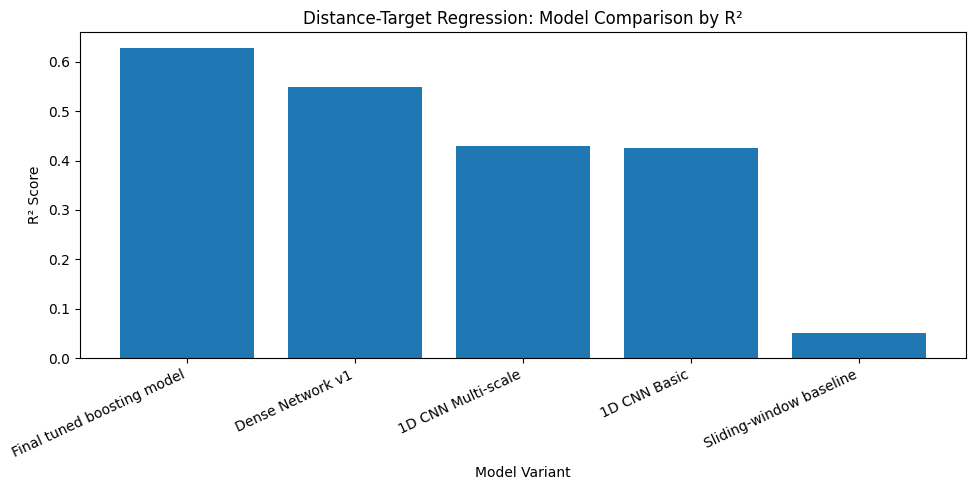

In [7]:
import matplotlib.pyplot as plt

plot_df = dist_df.dropna(subset=["R2"]).copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Variant"], plot_df["R2"])
plt.ylabel("R² Score")
plt.xlabel("Model Variant")
plt.title("Distance-Target Regression: Model Comparison by R²")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

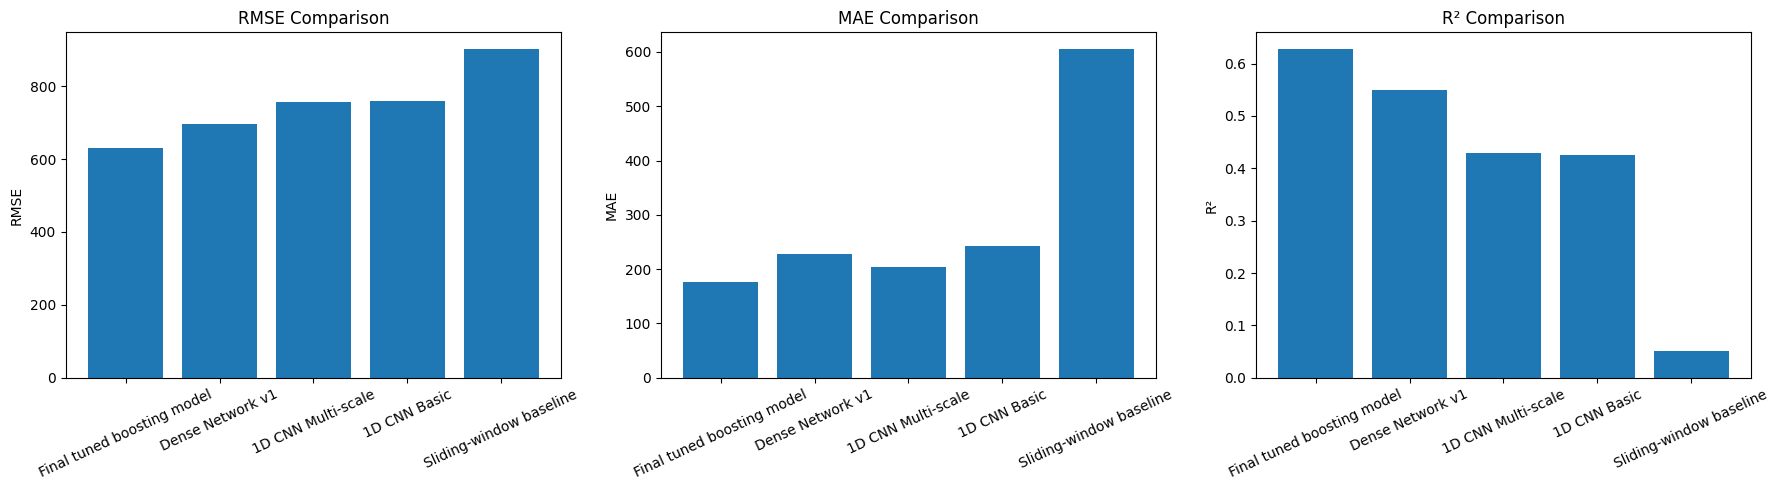

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(plot_df["Variant"], plot_df["RMSE"])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(plot_df["Variant"], plot_df["MAE"])
axes[1].set_title("MAE Comparison")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=25)

axes[2].bar(plot_df["Variant"], plot_df["R2"])
axes[2].set_title("R² Comparison")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [9]:
latex_abs = paper_abs_df[
    ["Model", "Variant", "TargetType", "RMSE", "MAE", "R2"]
].to_latex(
    index=False,
    escape=True,
    float_format="%.4f",
    caption="Performance of early absolute-coordinate regression models on CASP9-derived residue features.",
    label="tab:absolute_coordinate_models"
)

print(latex_abs)

\begin{table}
\caption{Performance of early absolute-coordinate regression models on CASP9-derived residue features.}
\label{tab:absolute_coordinate_models}
\begin{tabular}{lllrrr}
\toprule
Model & Variant & TargetType & RMSE & MAE & R2 \\
\midrule
XGBoost / Tree Ensemble & Early boosting baseline & Absolute XYZ coordinates & 855.1082 & 577.7850 & 0.1474 \\
Linear Regression & Baseline & Absolute XYZ coordinates & 910.5480 & 646.0600 & 0.0254 \\
SVR & RBF Kernel & Absolute XYZ coordinates & 914.2172 & 630.8270 & 0.0254 \\
\bottomrule
\end{tabular}
\end{table}



In [10]:
latex_abs = paper_abs_df[
    ["Model", "Variant", "TargetType", "RMSE", "MAE", "R2"]
].to_latex(
    index=False,
    escape=True,
    float_format="%.4f",
    caption="Performance of early absolute-coordinate regression models on CASP9-derived residue features.",
    label="tab:absolute_coordinate_models"
)

print(latex_abs)

\begin{table}
\caption{Performance of early absolute-coordinate regression models on CASP9-derived residue features.}
\label{tab:absolute_coordinate_models}
\begin{tabular}{lllrrr}
\toprule
Model & Variant & TargetType & RMSE & MAE & R2 \\
\midrule
XGBoost / Tree Ensemble & Early boosting baseline & Absolute XYZ coordinates & 855.1082 & 577.7850 & 0.1474 \\
Linear Regression & Baseline & Absolute XYZ coordinates & 910.5480 & 646.0600 & 0.0254 \\
SVR & RBF Kernel & Absolute XYZ coordinates & 914.2172 & 630.8270 & 0.0254 \\
\bottomrule
\end{tabular}
\end{table}



In [11]:
dist_ranked = dist_df.copy()
dist_ranked["Rank_by_R2"] = dist_ranked["R2"].rank(ascending=False, method="dense")
dist_ranked = dist_ranked.sort_values(by="Rank_by_R2").reset_index(drop=True)
dist_ranked

,ExperimentGroup,Model,Variant,InputRepresentation,TargetType,ArchitectureNotes,RMSE,MAE,R2,Rank_by_R2
0,Distance Target Regression,XGBoost,Final tuned boosting model,Sliding window (11x41 -> 451 flattened),"dist_i1, dist_i2, dist_i4, dist_i8",Best-performing model on engineered local cont...,629.388642,175.754974,0.628104,1.0
1,Distance Target Regression,MLP,Dense Network v1,"Sliding window (11x41), flattened inside network","dist_i1, dist_i2, dist_i4, dist_i8",451 -> 512 -> 256 -> 128 -> 4 with ReLU and dr...,695.434217,228.092834,0.548575,2.0
2,Distance Target Regression,CNN,1D CNN Multi-scale,Sliding window (11x41) as sequence tensor,"dist_i1, dist_i2, dist_i4, dist_i8","Parallel Conv1D branches (k=3,5,7) + fusion + ...",757.451772,204.029114,0.428885,3.0
3,Distance Target Regression,CNN,1D CNN Basic,Sliding window (11x41) as sequence tensor,"dist_i1, dist_i2, dist_i4, dist_i8",Stacked Conv1D blocks + BatchNorm + AdaptiveAv...,759.067973,242.078812,0.425308,4.0
4,Distance Target Regression,SVR,Sliding-window baseline,Sliding window (11x41 -> 451 flattened),"dist_i1, dist_i2, dist_i4, dist_i8",Linear baseline on final distance-target setup,902.542971,605.790300,0.050154,5.0


Honest interpretation to use in the paper

Based on what you have so far, the correct interpretation is:

Early stage

Direct prediction of absolute XYZ coordinates performed poorly.

Linear and SVR-style baselines explained very little variance.

This supports the conclusion that global coordinates are not directly learnable from local evolutionary residue features alone, due to translation-frame dependence and missing structural context.

Final stage

Reformulating the task as distance-target regression substantially improved performance.

Among the evaluated models, XGBoost achieved the best overall results.

Neural architectures including MLP and 1D CNN variants did not surpass XGBoost on the engineered local-window representation.

This suggests that, for the present feature design, tree-based boosted models are more compatible with the available signal than the tested neural models.